# 11 — Store-Level Stockout Analysis
## SunnyBest Retail Forecasting System

### Questions this notebook answers

| # | Question |
|---|----------|
| 1 | Which stores experience the most stockouts? |
| 2 | How frequently do stockouts occur (rate, not just count)? |
| 3 | Are there trends over time — getting better or worse? |
| 4 | Do store size or region explain the pattern? |

### What is a stockout?
A **stockout** is any observation where a store's inventory for a product hits zero (`stock_level = 0`).  
We also use an explicit `stockout_flag` column if it exists in the data.  

> **Stockout rate** = stockout observations ÷ total observations per store  
> This is more honest than raw counts — larger stores appear more often in the data and will always have higher counts even if they are better managed.

---
## 0. Setup & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from sqlalchemy import create_engine
from urllib.parse import quote_plus

warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

plt.rcParams["figure.figsize"]   = (14, 5)
plt.rcParams["axes.spines.top"]  = False
plt.rcParams["axes.spines.right"]= False
PALETTE = ["#4C72B0","#C44E52","#55A868","#DD8452","#8172B2","#64B5CD","#CCB974","#777777"]

host     = "aws-1-eu-central-1.pooler.supabase.com"
port     = 5432
database = "postgres"
user     = "postgres.ogkdfmkybqtrsglcizzt"
password = quote_plus("Bonabosssfs01")

engine = create_engine(
    f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}",
    pool_pre_ping=True
)

df_calendar   = pd.read_sql("SELECT * FROM core.dim_calendar ORDER BY date ASC", engine)
df_products   = pd.read_sql("SELECT * FROM core.dim_products ORDER BY product_id ASC", engine)
df_stores     = pd.read_sql("SELECT * FROM core.dim_stores ORDER BY store_id ASC", engine)
df_sales      = pd.read_sql("SELECT * FROM core.fact_sales ORDER BY date ASC", engine)
df_inventory  = pd.read_sql("SELECT * FROM core.fact_inventory ORDER BY date ASC", engine)

for d in [df_sales, df_inventory, df_calendar]:
    d["date"] = pd.to_datetime(d["date"])

print(f"Inventory rows : {len(df_inventory):,}")
print(f"Stores         : {df_stores['store_id'].nunique()}")
print(f"Inventory cols : {list(df_inventory.columns)}")

Inventory rows : 0
Stores         : 0
Inventory cols : ['date', 'store_id', 'product_id', 'starting_inventory', 'restock_qty', 'ending_inventory', 'stockout_flag']


---
## 1. Define Stockouts & Baseline Stats

In [2]:
inv = df_inventory.merge(df_stores, on="store_id", how="left")
inv = inv.merge(df_calendar[["date","season","month","is_weekend","is_holiday"]], on="date", how="left")

if "stockout_flag" in inv.columns:
    inv["is_stockout"] = inv["stockout_flag"].fillna(0).astype(int)
    print("Using stockout_flag column")
else:
    inv["is_stockout"] = (inv["stock_level"].fillna(0) == 0).astype(int)
    print("Derived stockout from stock_level == 0")

total = inv["is_stockout"].sum()
rate  = inv["is_stockout"].mean() * 100
print(f"\nTotal stockout observations : {total:,}")
print(f"Overall stockout rate        : {rate:.2f}%")
print(f"Date range                   : {inv['date'].min().date()} to {inv['date'].max().date()}")

Using stockout_flag column

Total stockout observations : 0
Overall stockout rate        : nan%
Date range                   : NaT to NaT


---
## 2. Which Stores Have the Most Stockouts?

> The left chart shows raw counts — useful for prioritising absolute impact.  
> The right chart shows stockout **rate** — the fair comparison across stores of different sizes.

,store_name,store_size,city,stockout_days,stockout_rate_pct


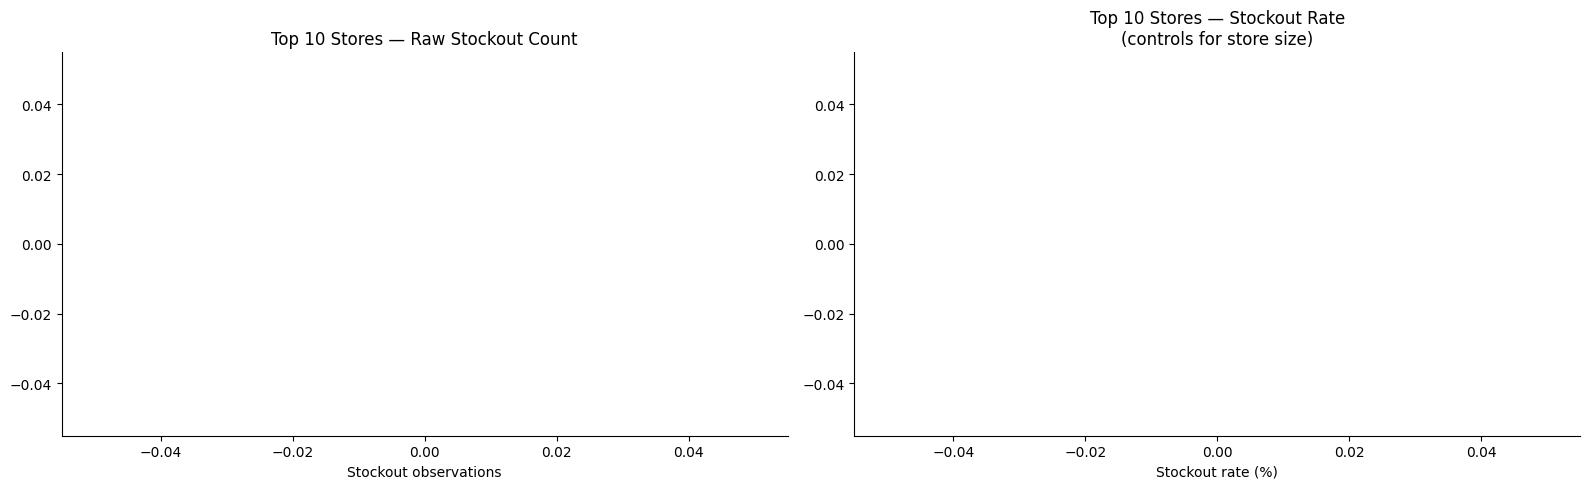

In [3]:
store_summary = (inv.groupby(["store_id","store_name","store_size","city","region"])
                   .agg(total_obs    =("is_stockout","count"),
                        stockout_days=("is_stockout","sum"))
                   .reset_index())
store_summary["stockout_rate_pct"] = (
    store_summary["stockout_days"] / store_summary["total_obs"] * 100
).round(2)
store_summary = store_summary.sort_values("stockout_rate_pct", ascending=False)

display(store_summary[["store_name","store_size","city","stockout_days","stockout_rate_pct"]].head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top10_count = store_summary.sort_values("stockout_days", ascending=False).head(10)
axes[0].barh(top10_count["store_name"][::-1], top10_count["stockout_days"][::-1], color=PALETTE[1])
axes[0].set_xlabel("Stockout observations")
axes[0].set_title("Top 10 Stores — Raw Stockout Count")

top10_rate = store_summary.head(10)
axes[1].barh(top10_rate["store_name"][::-1], top10_rate["stockout_rate_pct"][::-1], color=PALETTE[0])
axes[1].set_xlabel("Stockout rate (%)")
axes[1].set_title("Top 10 Stores — Stockout Rate\n(controls for store size)")

plt.tight_layout()
plt.show()

---
## 3. Stockout Rate by Store Size & Region

> If small stores have a higher stockout rate it points to a **replenishment frequency** problem — small stores get restocked less often.  
> If a specific region dominates, it may be a **logistics or supply chain** issue.

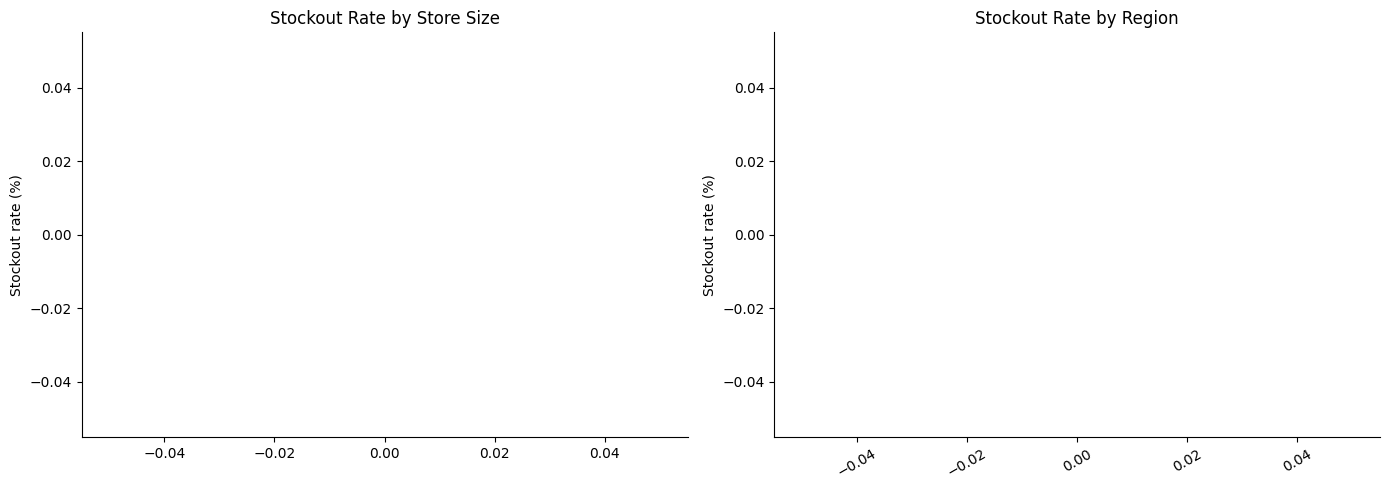

In [4]:
size_summary = (inv.groupby("store_size")
                  .agg(stockout_rate=("is_stockout","mean"))
                  .reset_index())
size_summary["stockout_rate"] *= 100

region_summary = (inv.groupby("region")
                    .agg(stockout_rate=("is_stockout","mean"))
                    .reset_index()
                    .sort_values("stockout_rate", ascending=False))
region_summary["stockout_rate"] *= 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(size_summary["store_size"], size_summary["stockout_rate"],
            color=PALETTE[:len(size_summary)])
axes[0].set_ylabel("Stockout rate (%)")
axes[0].set_title("Stockout Rate by Store Size")
for i, row in size_summary.iterrows():
    axes[0].text(i, row["stockout_rate"] + 0.3, f"{row['stockout_rate']:.1f}%",
                 ha="center", fontsize=9)

axes[1].bar(region_summary["region"], region_summary["stockout_rate"],
            color=PALETTE[:len(region_summary)])
axes[1].set_ylabel("Stockout rate (%)")
axes[1].set_title("Stockout Rate by Region")
axes[1].tick_params(axis="x", rotation=30)
for i, row in region_summary.reset_index().iterrows():
    axes[1].text(i, row["stockout_rate"] + 0.3, f"{row['stockout_rate']:.1f}%",
                 ha="center", fontsize=9)

plt.tight_layout()
plt.show()

---
## 4. Trends Over Time — Are Stockouts Getting Better or Worse?

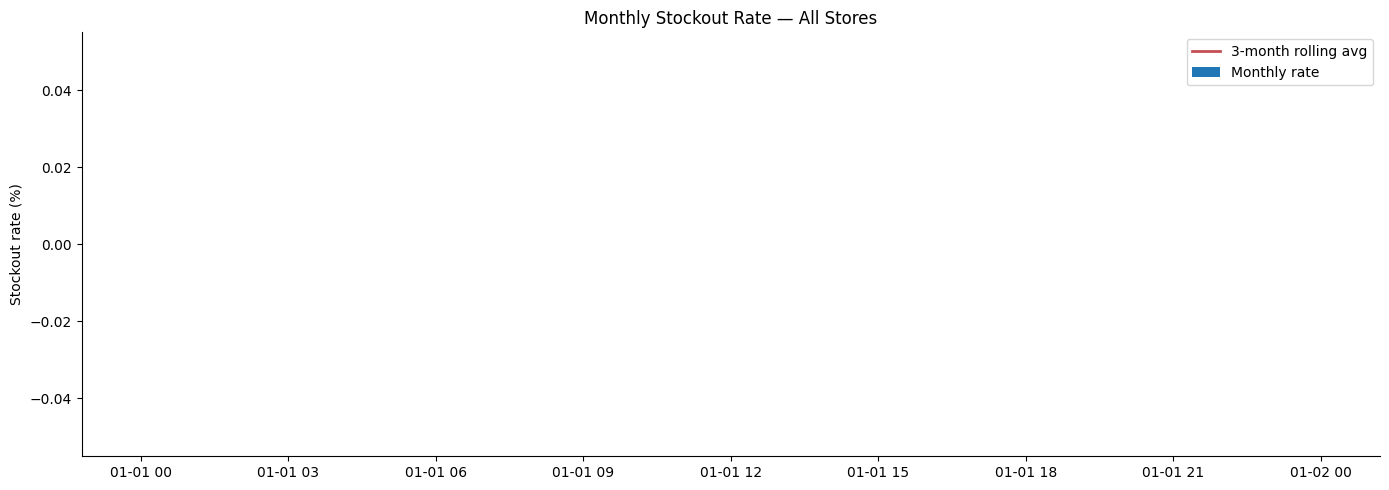

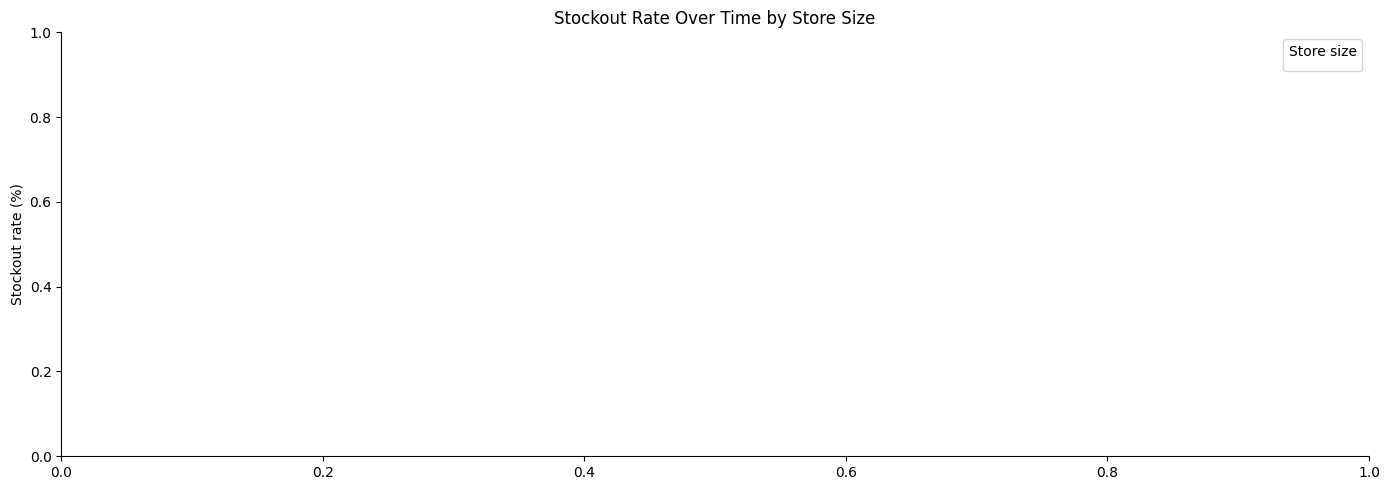

First half avg rate  : nan%
Second half avg rate : nan%
Overall trend        : WORSENING


In [5]:
inv["year_month"] = inv["date"].dt.to_period("M")

monthly = (inv.groupby("year_month")
             .agg(stockout_rate =("is_stockout","mean"),
                  stockout_count=("is_stockout","sum"))
             .reset_index())
monthly["year_month_dt"] = monthly["year_month"].dt.to_timestamp()
monthly["stockout_rate"] *= 100
monthly["trend_3m"] = monthly["stockout_rate"].rolling(3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly["year_month_dt"], monthly["stockout_rate"], width=20,
       color=PALETTE[0], alpha=0.5, label="Monthly rate")
ax.plot(monthly["year_month_dt"], monthly["trend_3m"],
        color=PALETTE[1], lw=2, label="3-month rolling avg")
ax.set_ylabel("Stockout rate (%)")
ax.set_title("Monthly Stockout Rate — All Stores")
ax.legend()
plt.tight_layout()
plt.show()

# Trend by store size
monthly_size = (inv.groupby(["year_month","store_size"])
                  .agg(stockout_rate=("is_stockout","mean"))
                  .reset_index())
monthly_size["year_month_dt"] = monthly_size["year_month"].dt.to_timestamp()
monthly_size["stockout_rate"] *= 100

fig, ax = plt.subplots(figsize=(14, 5))
for i, (sz, grp) in enumerate(monthly_size.groupby("store_size")):
    ax.plot(grp["year_month_dt"], grp["stockout_rate"],
            label=sz, color=PALETTE[i % len(PALETTE)], lw=1.5)
ax.set_ylabel("Stockout rate (%)")
ax.set_title("Stockout Rate Over Time by Store Size")
ax.legend(title="Store size")
plt.tight_layout()
plt.show()

first_half  = monthly.iloc[:len(monthly)//2]["stockout_rate"].mean()
second_half = monthly.iloc[len(monthly)//2:]["stockout_rate"].mean()
direction   = "IMPROVING" if second_half < first_half else "WORSENING"
print(f"First half avg rate  : {first_half:.2f}%")
print(f"Second half avg rate : {second_half:.2f}%")
print(f"Overall trend        : {direction}")

---
## 5. Store × Month Heatmap

> Dark cells = stores with persistent stockout problems.  
> A store that is dark every month needs a **policy change** — not a one-off fix.

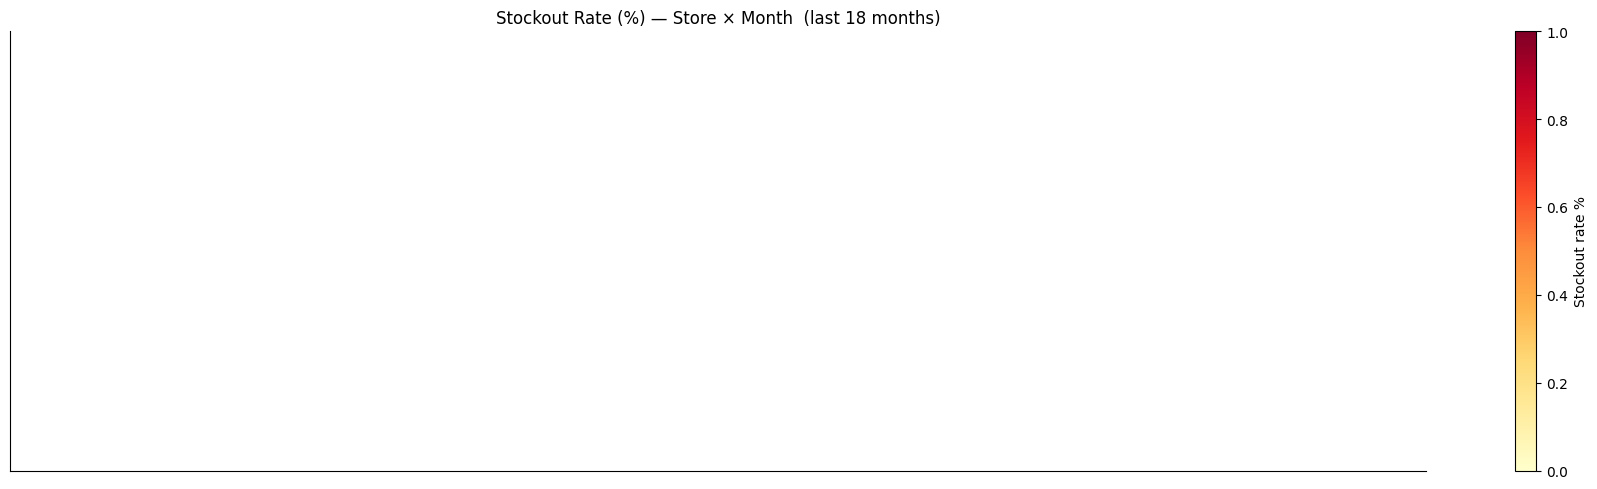

In [6]:
inv["month_label"] = inv["date"].dt.strftime("%Y-%m")

pivot = (inv.groupby(["store_name","month_label"])
           .agg(stockout_rate=("is_stockout","mean"))
           .reset_index()
           .assign(stockout_rate=lambda x: x["stockout_rate"] * 100)
           .pivot(index="store_name", columns="month_label", values="stockout_rate")
           .fillna(0))

pivot = pivot[sorted(pivot.columns)[-18:]]

fig, ax = plt.subplots(figsize=(18, max(5, len(pivot) * 0.5)))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto", vmin=0)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_title("Stockout Rate (%) — Store × Month  (last 18 months)")
plt.colorbar(im, ax=ax, label="Stockout rate %")
plt.tight_layout()
plt.show()

---
## 6. Revenue at Risk

> Multiply stockout observations by average daily revenue per store-product.  
> This is a **lower-bound estimate** — it assumes zero sales on stockout days.

,store_id,store_name,estimated_lost_revenue,stockout_events


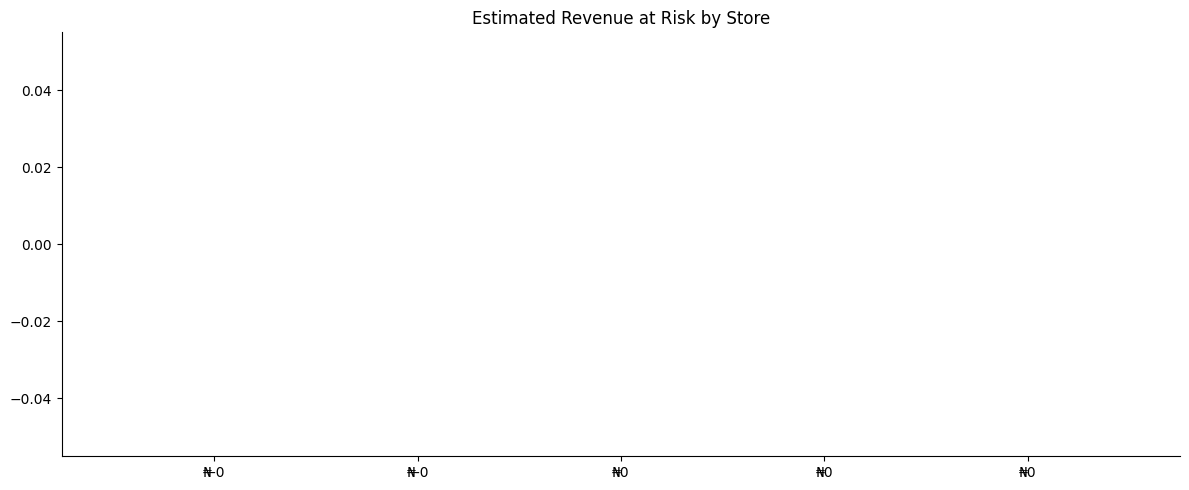

Total estimated revenue at risk: ₦0


In [7]:
sales_avg = (df_sales.groupby(["store_id","product_id"])
               .agg(avg_daily_units=("units_sold","mean"),
                    avg_price      =("price","mean"))
               .reset_index())
sales_avg["avg_daily_revenue"] = sales_avg["avg_daily_units"] * sales_avg["avg_price"]

stockout_rows = inv[inv["is_stockout"] == 1].copy()

if "product_id" in stockout_rows.columns:
    sto = stockout_rows.merge(sales_avg, on=["store_id","product_id"], how="left")
    sto["estimated_lost_revenue"] = sto["avg_daily_revenue"].fillna(0)

    store_loss = (sto.groupby(["store_id","store_name"])
                    .agg(estimated_lost_revenue=("estimated_lost_revenue","sum"),
                         stockout_events       =("is_stockout","sum"))
                    .reset_index()
                    .sort_values("estimated_lost_revenue", ascending=False))

    display(store_loss.head(10))

    fig, ax = plt.subplots(figsize=(12, 5))
    top = store_loss.head(10)
    ax.barh(top["store_name"][::-1], top["estimated_lost_revenue"][::-1], color=PALETTE[1])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"₦{v:,.0f}"))
    ax.set_title("Estimated Revenue at Risk by Store")
    plt.tight_layout()
    plt.show()

    total_lost = store_loss["estimated_lost_revenue"].sum()
    print(f"Total estimated revenue at risk: ₦{total_lost:,.0f}")
else:
    print("product_id not in inventory table — skipping revenue-at-risk calculation.")

---
## 7. Insights

**What this analysis tells you:**
- The stores with the highest **raw counts** and highest **rates** are often different — rate is the correct metric to compare across stores
- If small stores consistently have higher rates, the problem is **replenishment frequency**, not demand
- A store that is dark on the heatmap month after month needs a **policy change** — increasing order frequency or safety stock — not a one-off restock
- The revenue-at-risk number translates a statistical problem into a commercial one — use it to get management attention

**Sharp questions to ask about this analysis:**
1. Are we comparing counts or rates? Always rates for cross-store comparison
2. Is the trend seasonal (spikes every December) or structural (steadily rising)? They have different fixes
3. For the worst stores — what is their current reorder frequency and safety stock policy?
4. Has anything changed operationally (new supplier, new delivery route) that coincides with a stockout spike?